In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(
    "/home/harsha/Downloads/Welloop-Business-Analytics/Welloop-Business-Analytics/data/QualitativeCoding_DataAnalysis(Overall_Data).csv", 
    sep=';'
)


In [12]:
df.head()

,participant_id,session_id,participant_type,team_name,team_code,sport,birth_year,age_2026,gender,location,coach_interviewed,question_key,response_text,Unnamed: 13
0,T1_A01,T1,athlete,Uppsala Sirius U15,USR-U15,Football,2010,15,Male,"Uppsala, Sweden",no,Q1_Athlete,"I think it would be good. Yeah, great.",NaN
1,T1_A01,T1,athlete,Uppsala Sirius U15,USR-U15,Football,2010,15,Male,"Uppsala, Sweden",no,Q2_Athlete,"Yes, I think it's a motivation because it's ki...",NaN
2,T1_A01,T1,athlete,Uppsala Sirius U15,USR-U15,Football,2010,15,Male,"Uppsala, Sweden",no,Q3_Athlete,"Yeah, I think it would be alright.",NaN
3,T1_A01,T1,athlete,Uppsala Sirius U15,USR-U15,Football,2010,15,Male,"Uppsala, Sweden",no,Q4_Athlete,"Anything that, yeah, probably anything like fo...",NaN
4,T1_A01,T1,athlete,Uppsala Sirius U15,USR-U15,Football,2010,15,Male,"Uppsala, Sweden",no,Q5_Athlete,"Like probably chin pads, if it's not a too wor...",NaN


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   participant_id     651 non-null    str    
 1   session_id         651 non-null    str    
 2   participant_type   651 non-null    str    
 3   team_name          651 non-null    str    
 4   team_code          651 non-null    str    
 5   sport              651 non-null    str    
 6   birth_year         560 non-null    str    
 7   age_2026           651 non-null    str    
 8   gender             651 non-null    str    
 9   location           651 non-null    str    
 10  coach_interviewed  651 non-null    str    
 11  question_key       651 non-null    str    
 12  response_text      651 non-null    str    
 13  Unnamed: 13        0 non-null      float64
dtypes: float64(1), str(13)
memory usage: 115.6 KB


In [14]:
df = df.drop(columns=["Unnamed: 13"])

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   participant_id     651 non-null    str  
 1   session_id         651 non-null    str  
 2   participant_type   651 non-null    str  
 3   team_name          651 non-null    str  
 4   team_code          651 non-null    str  
 5   sport              651 non-null    str  
 6   birth_year         560 non-null    str  
 7   age_2026           651 non-null    str  
 8   gender             651 non-null    str  
 9   location           651 non-null    str  
 10  coach_interviewed  651 non-null    str  
 11  question_key       651 non-null    str  
 12  response_text      651 non-null    str  
dtypes: str(13)
memory usage: 107.4 KB


In [16]:
df.describe(include="all")

,participant_id,session_id,participant_type,team_name,team_code,sport,birth_year,age_2026,gender,location,coach_interviewed,question_key,response_text
count,651,651,651,651,651,651,560,651,651,651,651,651,651
unique,48,8,2,8,8,2,4,5,2,1,3,29,561
top,C2,T5,athlete,Uppsala IF U15,UIF-U15,Football,2010,15,Male,"Uppsala, Sweden",yes,Q1_Athlete,Yes
freq,16,139,507,139,139,515,260,260,507,651,403,39,12


In [17]:
df.isnull().sum()

participant_id       405
session_id           405
participant_type     405
team_name            405
team_code            405
sport                405
birth_year           496
age_2026             405
gender               405
location             405
coach_interviewed    405
question_key         405
response_text        405
dtype: int64

In [18]:
df["age_2026"] = pd.to_numeric(df["age_2026"], errors="coerce")

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   participant_id     651 non-null    str    
 1   session_id         651 non-null    str    
 2   participant_type   651 non-null    str    
 3   team_name          651 non-null    str    
 4   team_code          651 non-null    str    
 5   sport              651 non-null    str    
 6   birth_year         560 non-null    str    
 7   age_2026           416 non-null    float64
 8   gender             651 non-null    str    
 9   location           651 non-null    str    
 10  coach_interviewed  651 non-null    str    
 11  question_key       651 non-null    str    
 12  response_text      651 non-null    str    
dtypes: float64(1), str(12)
memory usage: 107.4 KB


In [20]:
df["age_2026"].unique()

array([15., 13., nan, 16.])

In [21]:
df[df["age_2026"].isna()][["participant_id", "participant_type", "age_2026"]].drop_duplicates()

,participant_id,participant_type,age_2026
208,T4_A01,athlete,NaN
221,T4_A02,athlete,NaN
234,T4_A03,athlete,NaN
247,T4_A04,athlete,NaN
260,T4_A05,athlete,NaN
273,T4_A06,athlete,NaN
286,T4_A07,athlete,NaN
507,C2,coach,NaN
523,C3,coach,NaN
539,C4,coach,NaN


In [22]:
import re

In [23]:
df["clean_text"] = df["response_text"]

In [24]:
df["clean_text"] = df["clean_text"].str.lower()

In [25]:
df[["response_text", "clean_text"]].head()

,response_text,clean_text
0,"I think it would be good. Yeah, great.","i think it would be good. yeah, great."
1,"Yes, I think it's a motivation because it's ki...","yes, i think it's a motivation because it's ki..."
2,"Yeah, I think it would be alright.","yeah, i think it would be alright."
3,"Anything that, yeah, probably anything like fo...","anything that, yeah, probably anything like fo..."
4,"Like probably chin pads, if it's not a too wor...","like probably chin pads, if it's not a too wor..."


In [28]:
df["clean_text"] = df["clean_text"].apply(
    lambda x: re.sub(r"[^\w\s]", "", x) if isinstance(x, str) else x
)


In [29]:
df[["response_text", "clean_text"]].head()

,response_text,clean_text
0,"I think it would be good. Yeah, great.",i think it would be good yeah great
1,"Yes, I think it's a motivation because it's ki...",yes i think its a motivation because its kind ...
2,"Yeah, I think it would be alright.",yeah i think it would be alright
3,"Anything that, yeah, probably anything like fo...",anything that yeah probably anything like foot...
4,"Like probably chin pads, if it's not a too wor...",like probably chin pads if its not a too worn ...


In [31]:
df["clean_text"] = df["clean_text"].str.replace(r"\s+", " ", regex=True).str.strip()

In [32]:
df[["response_text", "clean_text"]].head()

,response_text,clean_text
0,"I think it would be good. Yeah, great.",i think it would be good yeah great
1,"Yes, I think it's a motivation because it's ki...",yes i think its a motivation because its kind ...
2,"Yeah, I think it would be alright.",yeah i think it would be alright
3,"Anything that, yeah, probably anything like fo...",anything that yeah probably anything like foot...
4,"Like probably chin pads, if it's not a too wor...",like probably chin pads if its not a too worn ...


In [34]:
# Business Decision 1: Should Welloop Implement the Equipment Exchange Feature?

## Business Objective
## Evaluate whether the interview findings provide sufficient evidence to recommend implementing a token-based circular exchange system for sports equipment.

In [37]:
import pandas as pd
import re

In [38]:
q3 = df[df["question_key"] == "Q3_Athlete"].copy().reset_index(drop=True)

In [39]:
q3[["participant_id", "response_text"]]

,participant_id,response_text
0,T1_A01,"Yeah, I think it would be alright."
1,T1_A02,"I think I would be comfortable, and I think ma..."
2,T1_A03,"Yes, I would be comfortable"
3,T1_A04,Yes.If there's no fault
4,T1_A05,"Yeah, I would be comfortable"
5,T1_A06,"Yes,"
6,T1_A07,"Yes, that would be actually a good way from re..."
7,T1_A08,"Yeah, of course."
8,T2_A01,"Sounds very good, yeah, of course"
9,T2_A02,"Yes, of course"


In [41]:
codes = [1,1,1,1,1,1,1,1,1,1,1,1,1,2,1,1,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2
    
]

q3["adoption_code"] = codes

In [42]:
q3["adoption_code"] = codes

In [43]:
len(q3)

39

In [45]:
q3["adoption_code"].value_counts().sort_index()

adoption_code
1    35
2     4
Name: count, dtype: int64

In [46]:
adoption_summary = (
    q3["adoption_code"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(1)

adoption_summary

adoption_code
1    89.7
2    10.3
Name: proportion, dtype: float64

In [47]:
q10 = df[df["question_key"] == "Q10_Athlete"].copy().reset_index(drop=True)

In [48]:
q10[["participant_id", "response_text"]]

,participant_id,response_text
0,T1_A01,"Yes, I have. I've given away chin pads one tim..."
1,T1_A02,yes
2,T1_A03,"Yes, I have bought"
3,T1_A04,"Yeah, my chin pads, my old shin pads. Okay."
4,T1_A05,"Some shoes, Sports shoes."
5,T1_A06,"Yeah, I sold. Yeah, I sold. Okay.But when it w..."
6,T1_A07,"I've sold a lot of my old stuff, and I still do"
7,T1_A08,"I bought a shirt, pants, and Sports equipment"
8,T2_A01,"Yeah, Basketball shoes before"
9,T2_A02,"I personally have not, but I am hoping to start"


In [49]:
q10["dropout_code"] = ""

In [50]:
codes = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,4,1,2,2,1,4,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2
    
]

q10["dropout_code"] = codes

In [51]:
q10["dropout_code"].value_counts().sort_index()

dropout_code
1    32
2     5
4     2
Name: count, dtype: int64

In [52]:
dropout_summary = (
    q10["dropout_code"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(1)

dropout_summary

dropout_code
1    82.1
2    12.8
4     5.1
Name: proportion, dtype: float64

In [58]:
q16 = df[df["question_key"] == "Q16_Coach"].copy().reset_index(drop=True)

In [59]:
q16[["participant_id", "response_text"]]

,participant_id,response_text
0,C2,I think setting some rules and engaging more w...
1,C3,Does it work in your team? Does this concept w...
2,C4,"This concept should work. In hockey, I think. ..."
3,C5a,So that it could work in your team. I think an...
4,C5b,No explicitly answered
5,C5c,No explicitly answered
6,C6,In this specific thing i don't i don't really ...
7,C7,I Think it's already good
8,C8,Perhaps. Someone has to start. And then it goe...


In [62]:
codes = [2, 2, 1, 1, 3, 3, 4, 1, 2]

q16["feasibility_code"] = codes

In [63]:
q16["feasibility_code"].value_counts().sort_index()

feasibility_code
1    3
2    3
3    2
4    1
Name: count, dtype: int64

In [64]:
(
    q16["feasibility_code"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(1)

feasibility_code
1    33.3
2    33.3
3    22.2
4    11.1
Name: proportion, dtype: float64

In [66]:
q4 = df[df["question_key"] == "Q4_Athlete"].copy().reset_index(drop=True)

q5 = df[df["question_key"] == "Q5_Athlete"].copy().reset_index(drop=True)

q6 = df[df["question_key"] == "Q6_Athlete"].copy().reset_index(drop=True)

In [67]:
q4[["participant_id", "response_text"]]

,participant_id,response_text
0,T1_A01,"Anything that, yeah, probably anything like fo..."
1,T1_A02,"I think also football boots, chin guards and c..."
2,T1_A03,Maybe old shoes. Yes.
3,T1_A04,"Like old shoes, maybe that are so too little, ..."
4,T1_A05,chin pads. Yeah
5,T1_A06,anything if it's in a good condition
6,T1_A07,my shoes like my old shoes that I don't fit in...
7,T1_A08,"Everything, shoes, clothes, if they need."
8,T2_A01,Shoes
9,T2_A02,Shoes and Headbands


In [68]:
equipment_categories = {
    "Shoes": ["shoe", "shoes", "boot", "boots", "football boot", "football boots", "studs"],
    "Shin Pads": ["shin pad", "shin pads", "shinpad", "shinpads", "chin pad", "chin pads"],
    "Jerseys": ["jersey", "jerseys", "shirt", "shirts", "t-shirt", "tee shirt", "tee shirts"],
    "Shorts": ["short", "shorts"],
    "Gloves": ["glove", "gloves", "goalie glove", "goalie gloves"],
    "Backpacks": ["backpack", "backpacks", "bag"],
    "Jackets": ["jacket", "jackets"],
    "Headbands": ["headband", "headbands"],
    "Socks": ["sock", "socks", "grip socks"],
    "Training Equipment": ["training equipment", "training equipments"]
}

In [69]:
q4.columns

Index(['participant_id', 'session_id', 'participant_type', 'team_name',
       'team_code', 'sport', 'birth_year', 'age_2026', 'gender', 'location',
       'coach_interviewed', 'question_key', 'response_text', 'Unnamed: 13'],
      dtype='str')

In [70]:
q4 = df[df["question_key"] == "Q4_Athlete"].copy().reset_index(drop=True)

In [71]:
q4.columns

Index(['participant_id', 'session_id', 'participant_type', 'team_name',
       'team_code', 'sport', 'birth_year', 'age_2026', 'gender', 'location',
       'coach_interviewed', 'question_key', 'response_text', 'Unnamed: 13'],
      dtype='str')

In [72]:
df.columns

Index(['participant_id', 'session_id', 'participant_type', 'team_name',
       'team_code', 'sport', 'birth_year', 'age_2026', 'gender', 'location',
       'coach_interviewed', 'question_key', 'response_text', 'Unnamed: 13'],
      dtype='str')

In [74]:
import re

# Convert to lowercase
df["clean_text"] = df["response_text"].str.lower()

# Remove punctuation and normalize whitespace using vectorized regex
df["clean_text"] = (
    df["clean_text"].str.replace(r"[^\w\s]", "", regex=True).str.strip()
)


In [75]:
q4 = df[df["question_key"] == "Q4_Athlete"].copy().reset_index(drop=True)

In [76]:
q4.columns

Index(['participant_id', 'session_id', 'participant_type', 'team_name',
       'team_code', 'sport', 'birth_year', 'age_2026', 'gender', 'location',
       'coach_interviewed', 'question_key', 'response_text', 'Unnamed: 13',
       'clean_text'],
      dtype='str')

In [78]:
def extract_equipment(text):
    text = text.lower()
    found = []

    for category, keywords in equipment_categories.items():
        for keyword in keywords:
            if keyword in text:
                found.append(category)
                break

    return found

In [79]:
q4["equipment"] = q4["clean_text"].apply(extract_equipment)

In [80]:
q4[["response_text", "equipment"]].head(10)

,response_text,equipment
0,"Anything that, yeah, probably anything like fo...","[Shoes, Shin Pads, Jerseys, Training Equipment]"
1,"I think also football boots, chin guards and c...",[Shoes]
2,Maybe old shoes. Yes.,[Shoes]
3,"Like old shoes, maybe that are so too little, ...","[Shoes, Shin Pads]"
4,chin pads. Yeah,[Shin Pads]
5,anything if it's in a good condition,[]
6,my shoes like my old shoes that I don't fit in...,"[Shoes, Jerseys]"
7,"Everything, shoes, clothes, if they need.",[Shoes]
8,Shoes,[Shoes]
9,Shoes and Headbands,"[Shoes, Headbands]"


In [81]:
from collections import Counter

equipment_counts = Counter()

for items in q4["equipment"]:
    equipment_counts.update(items)

equipment_counts

Counter({'Shoes': 22,
         'Jerseys': 12,
         'Shin Pads': 11,
         'Shorts': 6,
         'Gloves': 4,
         'Backpacks': 3,
         'Training Equipment': 2,
         'Jackets': 2,
         'Headbands': 1,
         'Socks': 1})

In [83]:
from collections import Counter

equipment_counts = Counter()

for items in q4["equipment"]:
    equipment_counts.update(items)

equipment_df["Share (%)"] = (
    equipment_df["Mentions"] / equipment_df["Mentions"].sum() * 100
).round(1)

equipment_df

In [86]:
equipment_df = pd.DataFrame(
    equipment_counts.items(),
    columns=["Equipment", "Mentions"]
)

equipment_df = equipment_df.sort_values(
    by="Mentions",
    ascending=False
).reset_index(drop=True)

In [87]:
equipment_df["Share (%)"] = (
    equipment_df["Mentions"] / equipment_df["Mentions"].sum() * 100
).round(1)

equipment_df

,Equipment,Mentions,Share (%)
0,Shoes,22,34.4
1,Jerseys,12,18.8
2,Shin Pads,11,17.2
3,Shorts,6,9.4
4,Gloves,4,6.2
5,Backpacks,3,4.7
6,Jackets,2,3.1
7,Training Equipment,2,3.1
8,Headbands,1,1.6
9,Socks,1,1.6


In [88]:
q5 = df[df["question_key"] == "Q5_Athlete"].copy().reset_index(drop=True)

In [89]:
q5.columns

Index(['participant_id', 'session_id', 'participant_type', 'team_name',
       'team_code', 'sport', 'birth_year', 'age_2026', 'gender', 'location',
       'coach_interviewed', 'question_key', 'response_text', 'Unnamed: 13',
       'clean_text'],
      dtype='str')

In [90]:
q5["equipment"] = q5["clean_text"].apply(extract_equipment)

In [91]:
from collections import Counter

potential_supply = Counter()

for items in q5["equipment"]:
    potential_supply.update(items)

potential_supply

Counter({'Shoes': 22,
         'Jerseys': 12,
         'Shin Pads': 9,
         'Gloves': 4,
         'Jackets': 2,
         'Shorts': 2,
         'Socks': 1,
         'Backpacks': 1,
         'Headbands': 1,
         'Training Equipment': 1})

In [92]:
Counter({'Shoes': 22,
         'Jerseys': 12,
         'Shin Pads': 9,
         'Gloves': 4,
         'Jackets': 2,
         'Shorts': 2,
         'Socks': 1,
         'Backpacks': 1,
         'Headbands': 1,
         'Training Equipment': 1})

Counter({'Shoes': 22,
         'Jerseys': 12,
         'Shin Pads': 9,
         'Gloves': 4,
         'Jackets': 2,
         'Shorts': 2,
         'Socks': 1,
         'Backpacks': 1,
         'Headbands': 1,
         'Training Equipment': 1})

In [94]:
equipment_df.head()

,Equipment,Mentions,Share (%)
0,Shoes,22,34.4
1,Jerseys,12,18.8
2,Shin Pads,11,17.2
3,Shorts,6,9.4
4,Gloves,4,6.2


In [96]:
potential_supply_df = pd.DataFrame(
    potential_supply.items(),
    columns=["Equipment", "Potential Supply"]
).sort_values("Potential Supply", ascending=False).reset_index(drop=True)

In [97]:
comparison_df = pd.merge(
    equipment_df,
    potential_supply_df,
    on="Equipment",
    how="outer"
)

comparison_df

,Equipment,Mentions,Share (%),Potential Supply
0,Backpacks,3,4.7,1
1,Gloves,4,6.2,4
2,Headbands,1,1.6,1
3,Jackets,2,3.1,2
4,Jerseys,12,18.8,12
5,Shin Pads,11,17.2,9
6,Shoes,22,34.4,22
7,Shorts,6,9.4,2
8,Socks,1,1.6,1
9,Training Equipment,2,3.1,1


In [98]:
comparison_df["Gap"] = comparison_df["Potential Supply"] - comparison_df["Mentions"]

In [99]:
def recommendation(gap):
    if gap >= 0:
        return "Ready for MVP"
    elif gap >= -2:
        return "Monitor Supply"
    else:
        return "Increase Donations"

comparison_df["Recommendation"] = comparison_df["Gap"].apply(recommendation)

In [101]:
comparison_df.sort_values("Mentions", ascending=False)

,Equipment,Mentions,Share (%),Potential Supply,Gap,Recommendation
6,Shoes,22,34.4,22,0,Ready for MVP
4,Jerseys,12,18.8,12,0,Ready for MVP
5,Shin Pads,11,17.2,9,-2,Monitor Supply
7,Shorts,6,9.4,2,-4,Increase Donations
1,Gloves,4,6.2,4,0,Ready for MVP
0,Backpacks,3,4.7,1,-2,Monitor Supply
9,Training Equipment,2,3.1,1,-1,Monitor Supply
3,Jackets,2,3.1,2,0,Ready for MVP
2,Headbands,1,1.6,1,0,Ready for MVP
8,Socks,1,1.6,1,0,Ready for MVP


In [102]:
q6 = df[df["question_key"] == "Q6_Athlete"].copy().reset_index(drop=True)

In [103]:
q6[["participant_id","response_text"]]

,participant_id,response_text
0,T1_A01,"prefer through app Yes, that would be much mor..."
1,T1_A02,I think at practice it would be more simpler.B...
2,T1_A03,Through the app
3,T1_A04,Through the app.
4,T1_A05,I would say through the app.
5,T1_A06,"Training, maybe. Training, practice session. Y..."
6,T1_A07,Through app since it's maybe the person doesn'...
7,T1_A08,"Yeah, everything. It doesn't matter, it doesn'..."
8,T2_A01,"Through the app, it is convenient"
9,T2_A02,App too


In [106]:
methods = [
1,2,1,1,2,1,3,3,1,1,
2,1,1,1,2,1,1,1,2,2,
2,3,3,1,1,1,1,1,1,1,
2,1,1,2,2,1,3,3,3
]

q6["exchange_method"] = methods

In [107]:
q6["exchange_method"].value_counts().sort_index()

exchange_method
1    22
2    10
3     7
Name: count, dtype: int64

In [109]:
q7 = df[df["question_key"] == "Q7_Athlete"].copy().reset_index(drop=True)
q8 = df[df["question_key"] == "Q8_Athlete"].copy().reset_index(drop=True)
q9 = df[df["question_key"] == "Q9_Athlete"].copy().reset_index(drop=True)
q11 = df[df["question_key"] == "Q11_Athlete"].copy().reset_index(drop=True)
q12 = df[df["question_key"] == "Q12_Athlete"].copy().reset_index(drop=True)

In [110]:
risk_dictionary = {
    "Trust": ["trust", "trustworthy", "comfortable", "know"],
    "Scams": ["scam", "scammed", "misused"],
    "Quality": ["quality", "condition", "good condition"],
    "Hygiene": ["dirty", "hygiene", "clean", "sweat", "sanitary"],
    "Fairness": ["fair", "unfair", "give back", "contribute", "tokens"],
    "User Adoption": ["enough people", "many users", "a lot of users", "community"],
    "Communication": ["communication"],
    "Wrong Size": ["size", "sizes"]
}

In [111]:
def extract_risks(text):
    text = text.lower()
    found = []

    for category, keywords in risk_dictionary.items():
        for keyword in keywords:
            if keyword in text:
                found.append(category)
                break

    return found

In [112]:
risk_df = pd.concat([q7, q8, q9, q11, q12], ignore_index=True)

In [113]:
risk_df["risk"] = risk_df["clean_text"].apply(extract_risks)

In [114]:
from collections import Counter

risk_counts = Counter()

for r in risk_df["risk"]:
    risk_counts.update(r)

risk_counts

Counter({'Trust': 33, 'Fairness': 9, 'User Adoption': 3, 'Scams': 2})

In [108]:
exchange_summary = (
    q6["exchange_method"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(1)

exchange_summary

exchange_method
1    56.4
2    25.6
3    17.9
Name: proportion, dtype: float64

## Business Finding 1: Athlete Adoption Readiness

### KPI Results

# Positive: 89.7%
# Conditional: 10.3%
# Neutral: 0%
# Negative: 0%

### Business Insight

#The findings indicate exceptionally strong athlete acceptance of a token-based circular sports equipment exchange. Nearly nine out of ten athletes expressed a clear willingness to participate, while the remaining responses supported the concept under conditions such as equipment quality, hygiene, or item condition.
m
#Importantly, no athlete rejected the concept, suggesting that resistance to adoption is minimal.

### Recommendation

#Proceed with the development of the equipment exchange feature. The Minimum Viable Product (MVP) should include equipment quality verification, condition descriptions, and trust mechanisms to address the concerns raised in conditional responses and maximize user adoption.

## Business Finding 2: Perceived Impact on Sports Dropout

### KPI Results

#Positive: 82.1%
#Conditional: 12.8%
#Negative: 5.1%

### Business Insight

#Most athletes believe that a token-based circular equipment exchange would help young athletes remain in sport by reducing financial barriers to accessing equipment.

#Conditional responses indicate that the system should provide quality assurance and reliable exchange processes to maximize its effectiveness.

### Recommendation

#The findings support implementing the feature as a mechanism to improve sports participation and reduce equipment-related dropout.

## Business Finding 3: Coach Feasibility Assessment

### KPI Results
#Positive: 33.3%
#Conditional: 44.4%
#Neutral: 22.2%
#Negative: 0.0%

### Business Insight

#Coaches generally support the concept of a token-based circular sports equipment exchange, although many believe its success depends on effective implementation. The most common concerns relate to user adoption, communication, trust, and ensuring sufficient participation to sustain the exchange ecosystem.

#Importantly, no coach explicitly opposed the concept, indicating that implementation barriers are operational rather than conceptual.

### Recommendation

#Proceed with implementation while prioritizing user onboarding, awareness campaigns, trust mechanisms, and clear operational guidelines. Coach engagement should be incorporated into the rollout strategy to encourage adoption within sports clubs.

# Executive Decision 1: Should Welloop Implement the Equipment Exchange Feature?

## Evidence Summary

| Evidence | Result |
|----------|--------|
| Athlete Adoption Readiness | 89.7% Positive, 10.3% Conditional |
| Perceived Impact on Sports Dropout | 82.1% Positive, 12.8% Conditional, 5.1% Negative |
| Coach Feasibility Assessment | 33.3% Positive, 44.4% Conditional, 22.2% Neutral, 0% Negative |

## Executive Recommendation

The interview findings provide strong evidence supporting the implementation of a token-based circular sports equipment exchange within the Welloop platform.

## Decision 2.1: Priority Equipment Categories for MVP

### KPI Results

| Equipment Category | Athlete Mentions |
|--------------------|-----------------:|
| Shoes | 22 |
| Jerseys | 12 |
| Shin Pads | 11 |
| Shorts | 6 |
| Gloves | 4 |
| Backpacks | 3 |
| Training Equipment | 2 |
| Jackets | 2 |
| Headbands | 1 |
| Socks | 1 |

### Business Insight

Athletes most frequently identified footwear, jerseys, and shin pads as the preferred equipment for exchange. These items represent the highest perceived value for reducing equipment costs and supporting continued participation in sport.

Lower-frequency items such as backpacks, jackets, and headbands indicate niche demand and can be introduced in later product releases.

### Product Recommendation

The MVP should prioritize the following equipment categories:

1. Shoes / Football Boots
2. Jerseys
3. Shin Pads
4. Shorts
5. Gloves

Lower-demand categories should be considered for future platform expansion after user adoption has been established.

## Decision 2.2: Equipment Demand vs Potential Supply

### Business Insight

Demand for shoes, jerseys, and shin pads is matched by strong willingness among athletes to donate these categories, indicating a healthy foundation for a circular exchange ecosystem.

However, categories such as shorts, backpacks, and training equipment exhibit lower potential supply relative to athlete demand. These categories may experience shortages during the initial launch and should be supported through targeted donation campaigns or community awareness initiatives.

### Product Recommendation

The MVP should prioritize equipment categories with both high demand and sufficient potential supply, specifically shoes, jerseys, and shin pads.

Categories with lower potential supply should remain available but require additional community engagement strategies to increase equipment donations before scaling the exchange system.

## Decision 2.3: Preferred Equipment Exchange Method

### KPI Results

| Exchange Method | Preference (%) |
|-----------------|---------------:|
| App | 56.4% |
| Training / Face-to-Face | 25.6% |
| Both / No Preference | 17.9% |

### Business Insight

More than half of the athletes prefer to coordinate equipment exchanges through the mobile application, highlighting a clear preference for a digital-first experience. However, approximately one-quarter of respondents prefer exchanging equipment during training sessions, while others are comfortable with either approach.

These findings indicate that athletes value both convenience and flexibility, depending on their relationship with the other participant and the context of the exchange.

### Product Recommendation

The MVP should adopt an **app-first exchange workflow** while allowing users to arrange in-person handovers during training sessions. This hybrid approach reduces logistical complexity, increases user convenience, and accommodates different user preferences.

## Decision 3: Product Risk Assessment

### KPI Results

| Product Risk | Mentions |
|--------------|---------:|
| Trust | 33 |
| Fairness | 9 |
| User Adoption | 3 |
| Scams | 2 |

### Business Insight

Trust is the dominant concern influencing adoption of the equipment exchange platform. Athletes frequently mentioned the importance of knowing the other participant, trusting the condition of exchanged items, or preferring exchanges within familiar teams.

Fairness was the second most common concern, with several participants expressing that the token economy should encourage reciprocal contributions rather than allowing users to receive equipment without participating in the exchange.

Scams and achieving sufficient user participation were also identified as implementation risks, although they were mentioned less frequently.

### Product Recommendations

To improve adoption and reduce implementation risk, the MVP should include:

- User verification and trusted profiles.
- Transparent item descriptions and condition ratings.
- Token rules that encourage reciprocal participation.
- Community onboarding campaigns to increase active users.
- In-app messaging to support communication between participants.

# Decision 4: Success Metrics for Post-Launch Evaluation

## Business Objective

Define the key performance indicators (KPIs) that Welloop should monitor after launching the equipment exchange feature.

### Recommended Business KPIs

| KPI | Business Purpose |
|------|------------------|
| Equipment Exchange Completion Rate | Measure successful exchanges. |
| Active Exchange Users | Track adoption of the feature. |
| Donation-to-Request Ratio | Monitor balance between demand and potential supply. |
| Most Exchanged Equipment Category | Identify high-performing equipment categories. |
| Repeat Exchange Rate | Measure continued user engagement. |
| Athlete Retention Rate | Evaluate whether the feature contributes to reducing sports dropout. |
| Average Time to Complete an Exchange | Assess platform efficiency. |
| Token Circulation Rate | Evaluate the effectiveness of the token-based incentive system. |

## Executive Recommendation

The success of the equipment exchange feature should not be measured solely by the number of exchanged items. Welloop should monitor user adoption, equipment circulation, contribution fairness, and athlete retention to evaluate whether the feature delivers long-term value to both users and sports organizations.

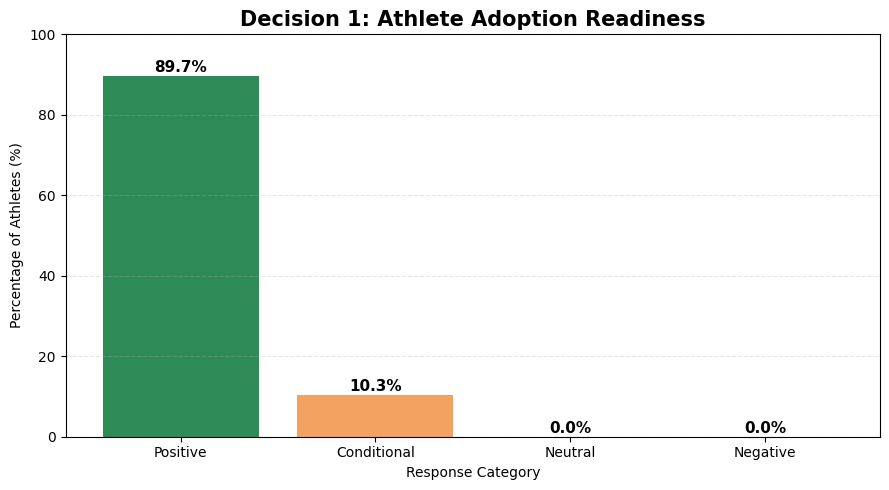

In [115]:
import matplotlib.pyplot as plt

adoption_chart = pd.DataFrame({
    "Category": ["Positive", "Conditional", "Neutral", "Negative"],
    "Percentage": [89.7, 10.3, 0.0, 0.0]
})

colors = [
    "#2E8B57",   # Positive
    "#F4A261",   # Conditional
    "#BDBDBD",   # Neutral
    "#D62828"    # Negative
]

plt.figure(figsize=(9,5))

bars = plt.bar(
    adoption_chart["Category"],
    adoption_chart["Percentage"],
    color=colors
)

plt.title(
    "Decision 1: Athlete Adoption Readiness",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Response Category")
plt.ylabel("Percentage of Athletes (%)")

plt.ylim(0,100)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "decision1_adoption_readiness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Business Insight

Nearly 90% of athletes expressed a positive willingness to use the token-based equipment exchange system, indicating strong market readiness. Only a small proportion of respondents expressed conditional support, primarily related to equipment quality and trust. No respondents rejected the concept.

**Business Recommendation**

Proceed with implementation while incorporating quality verification and trust mechanisms into the MVP.

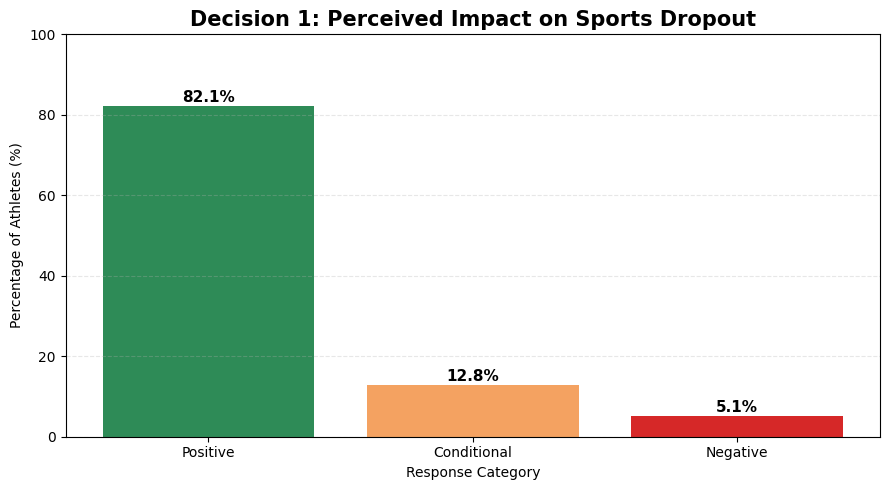

In [116]:
dropout_chart = pd.DataFrame({
    "Category": ["Positive", "Conditional", "Negative"],
    "Percentage": [82.1, 12.8, 5.1]
})

colors = [
    "#2E8B57",   # Positive
    "#F4A261",   # Conditional
    "#D62828"    # Negative
]

plt.figure(figsize=(9,5))

bars = plt.bar(
    dropout_chart["Category"],
    dropout_chart["Percentage"],
    color=colors
)

plt.title(
    "Decision 1: Perceived Impact on Sports Dropout",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Response Category")
plt.ylabel("Percentage of Athletes (%)")

plt.ylim(0,100)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "decision1_dropout_impact.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Business Insight

More than four out of five athletes believe that the equipment exchange feature can help reduce sports dropout by lowering equipment-related barriers. Only a small proportion expressed reservations or believed the impact would be limited.

**Business Recommendation**

Position the equipment exchange feature as a participation and retention initiative. Marketing and communication should emphasize affordability and accessibility, especially for young athletes who may face financial barriers.

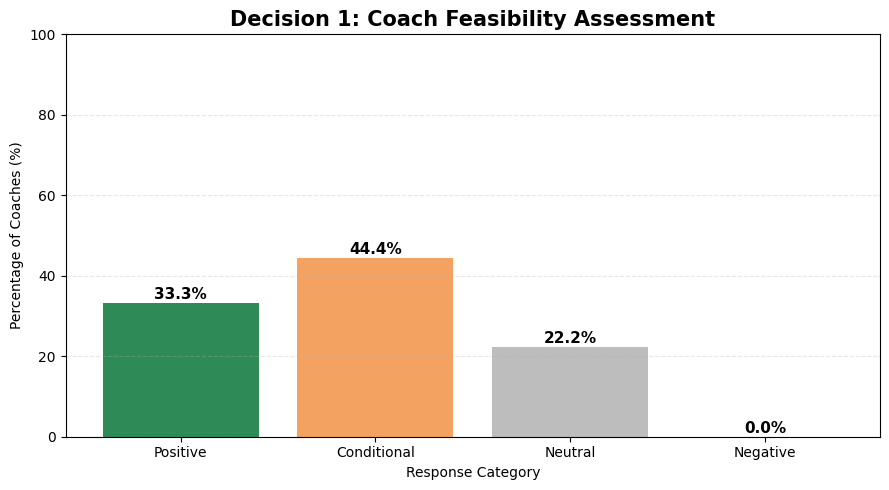

In [117]:
coach_chart = pd.DataFrame({
    "Category": ["Positive", "Conditional", "Neutral", "Negative"],
    "Percentage": [33.3, 44.4, 22.2, 0.0]
})

colors = [
    "#2E8B57",   # Positive
    "#F4A261",   # Conditional
    "#BDBDBD",   # Neutral
    "#D62828"    # Negative
]

plt.figure(figsize=(9,5))

bars = plt.bar(
    coach_chart["Category"],
    coach_chart["Percentage"],
    color=colors
)

plt.title(
    "Decision 1: Coach Feasibility Assessment",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Response Category")
plt.ylabel("Percentage of Coaches (%)")

plt.ylim(0,100)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figure3_coach_feasibility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Business Insight

While coaches expressed more caution than athletes, none rejected the concept outright. Most coaches either supported the idea directly or supported it under conditions such as adequate user participation, trust, and effective implementation.

**Business Recommendation**

Engage coaches early in the rollout strategy. Their support can increase awareness, build trust within clubs, and encourage adoption among athletes.

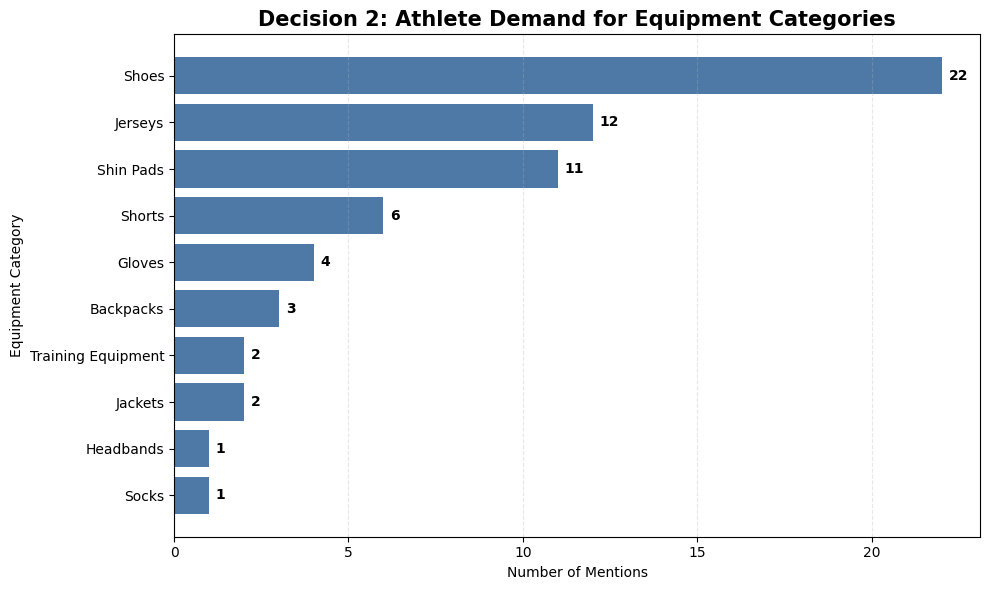

In [118]:
equipment_df = equipment_df.sort_values("Mentions", ascending=True)

plt.figure(figsize=(10,6))

bars = plt.barh(
    equipment_df["Equipment"],
    equipment_df["Mentions"],
    color="#4E79A7"
)

plt.title(
    "Decision 2: Athlete Demand for Equipment Categories",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Number of Mentions")
plt.ylabel("Equipment Category")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figure4_equipment_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Business Insight

Shoes are the most requested equipment category, accounting for the largest share of athlete demand. Jerseys and shin pads are the next most frequently requested items, indicating that these categories should form the core of the initial equipment exchange offering.

**Business Recommendation**

Launch the MVP with shoes, jerseys, and shin pads as priority categories. These items represent the highest demand and are likely to maximize early user engagement and exchange activity.

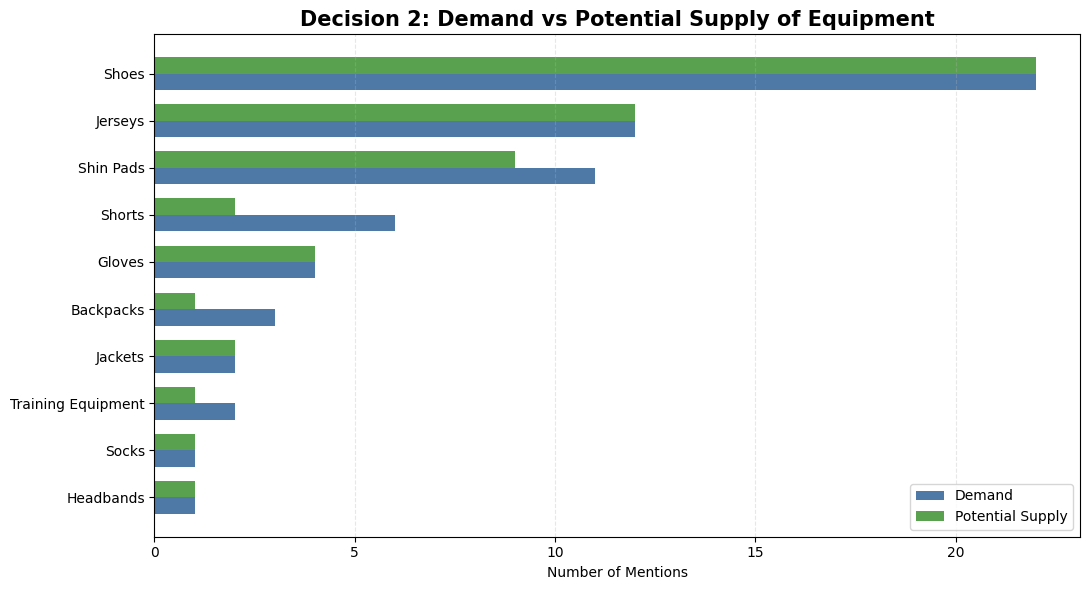

In [119]:
comparison_plot = comparison_df.sort_values("Mentions", ascending=True)

import numpy as np

y = np.arange(len(comparison_plot))
height = 0.35

plt.figure(figsize=(11,6))

plt.barh(
    y - height/2,
    comparison_plot["Mentions"],
    height,
    label="Demand",
    color="#4E79A7"
)

plt.barh(
    y + height/2,
    comparison_plot["Potential Supply"],
    height,
    label="Potential Supply",
    color="#59A14F"
)

plt.yticks(y, comparison_plot["Equipment"])

plt.xlabel("Number of Mentions")

plt.title(
    "Decision 2: Demand vs Potential Supply of Equipment",
    fontsize=15,
    weight="bold"
)

plt.legend()

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figure5_demand_vs_supply.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Business Insight

Demand and potential supply are well balanced for shoes and jerseys, suggesting these categories are strong candidates for launch. However, shorts and shin pads show lower potential supply relative to athlete demand, indicating that these categories may require additional donation campaigns or community engagement to maintain a healthy exchange ecosystem.

**Business Recommendation**

Launch the MVP with shoes, jerseys, and shin pads while implementing targeted donation campaigns for categories where potential supply is lower than athlete demand. Monitoring equipment availability after launch will help maintain a balanced marketplace.

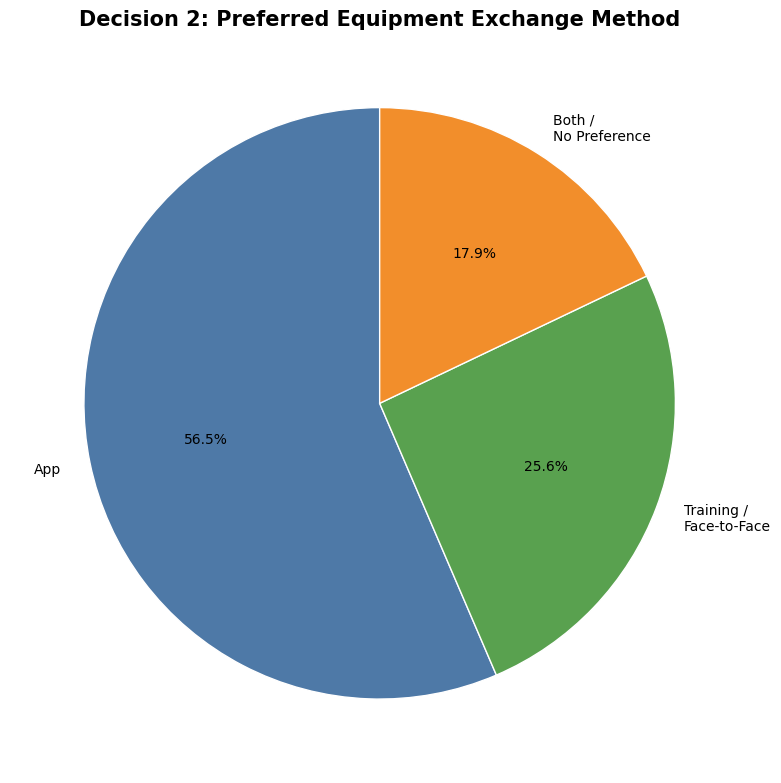

In [120]:
exchange_chart = pd.DataFrame({
    "Method": [
        "App",
        "Training /\nFace-to-Face",
        "Both /\nNo Preference"
    ],
    "Percentage": [56.4, 25.6, 17.9]
})

colors = [
    "#4E79A7",
    "#59A14F",
    "#F28E2B"
]

plt.figure(figsize=(8,8))

plt.pie(
    exchange_chart["Percentage"],
    labels=exchange_chart["Method"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor":"white"}
)

plt.title(
    "Decision 2: Preferred Equipment Exchange Method",
    fontsize=15,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "figure6_exchange_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Business Insight

More than half of the athletes prefer arranging exchanges through the mobile application, indicating a clear preference for a digital-first experience. However, a substantial proportion still value exchanging equipment during training sessions or are comfortable with either approach.

**Business Recommendation**

Develop the MVP as an app-first platform while supporting in-person handovers during training sessions. This hybrid approach provides flexibility without increasing operational complexity.

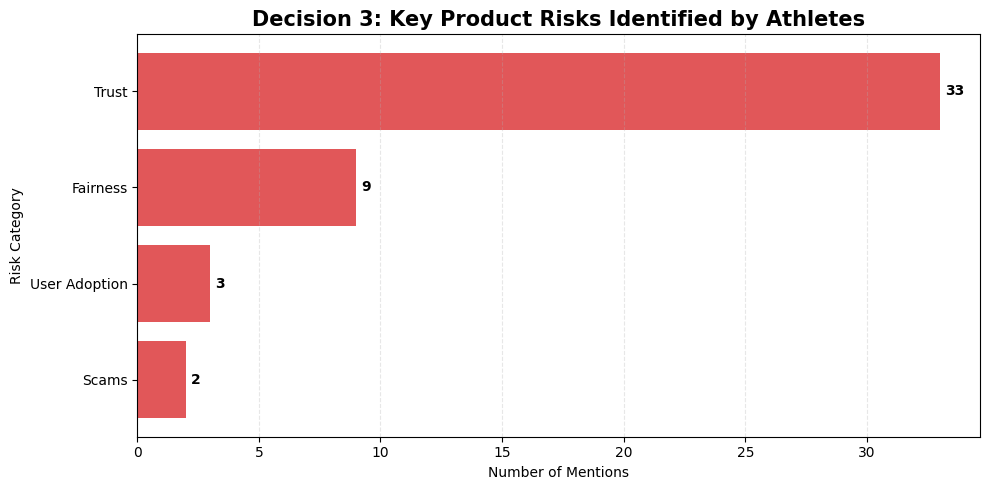

In [121]:
risk_chart = pd.DataFrame({
    "Risk": [
        "Trust",
        "Fairness",
        "User Adoption",
        "Scams"
    ],
    "Mentions": [33, 9, 3, 2]
})

risk_chart = risk_chart.sort_values("Mentions", ascending=True)

plt.figure(figsize=(10,5))

bars = plt.barh(
    risk_chart["Risk"],
    risk_chart["Mentions"],
    color="#E15759"
)

plt.title(
    "Decision 3: Key Product Risks Identified by Athletes",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Number of Mentions")
plt.ylabel("Risk Category")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figure7_product_risks.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Business Insight

Trust is by far the most significant concern among athletes, appearing substantially more frequently than any other implementation risk. Concerns about fairness, user participation, and scams were also identified but were considerably less common.

**Business Recommendation**

The MVP should prioritize trust-building mechanisms such as verified user profiles, equipment condition ratings, transparent exchange histories, and clear token rules. Addressing trust early is likely to have the greatest impact on user adoption.

In [122]:
risk_matrix = pd.DataFrame({
    "Risk": [
        "Trust",
        "Fairness",
        "User Adoption",
        "Scams"
    ],
    "Likelihood": [
        "High",
        "Medium",
        "Medium",
        "Low"
    ],
    "Business Impact": [
        "High",
        "High",
        "High",
        "Medium"
    ],
    "Priority": [
        "Critical",
        "High",
        "High",
        "Medium"
    ],
    "Recommended Mitigation": [
        "Verified profiles, ratings and condition checks",
        "Token contribution rules",
        "Club onboarding and awareness campaigns",
        "Reporting system and moderation"
    ]
})

risk_matrix

,Risk,Likelihood,Business Impact,Priority,Recommended Mitigation
0,Trust,High,High,Critical,"Verified profiles, ratings and condition checks"
1,Fairness,Medium,High,High,Token contribution rules
2,User Adoption,Medium,High,High,Club onboarding and awareness campaigns
3,Scams,Low,Medium,Medium,Reporting system and moderation
